# ML-08 — Capstone Modeling Lane

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/RaihanBasha7/flyrank-ml-internship/blob/main/work/notebooks/w05_model.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Method choice and why

*Which method from the toolkit, and why it fits your lane.*

## Method Choice and Why

For this capstone, I selected a Random Forest Classifier.

The Week 4 baseline provided a simple reference score. My goal this week is not to build the most complex model but to test whether a machine learning model can improve on the same dataset using the same evaluation process.

I selected Random Forest because:

- It handles non-linear relationships between features.
- It is robust to noisy data.
- It requires little preprocessing.
- It reduces overfitting compared with a single decision tree.
- It provides feature importance, making the results easier to interpret.

This model fits my lane because the task is supervised classification on structured tabular data.

In [24]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

import matplotlib.pyplot as plt

print("Libraries imported successfully.")

Libraries imported successfully.


## 2. Split design

*Grouped by client? Time-aware? Say why this split is honest for your question.*

## Split Design

I used a grouped 80/20 train-test split with `GroupShuffleSplit`.

The split is grouped by `client_id` so that content from the same client does not appear in both the training and testing sets. This provides a more honest evaluation because the model is tested on unseen clients instead of similar content from clients it has already seen.

A fixed random seed (`random_state=42`) was used to make the results reproducible.

In [25]:
import pandas as pd
from sklearn.model_selection import GroupShuffleSplit

# ----------------------------
# Load Dataset
# ----------------------------
df = pd.read_csv("data/raw/content_refresh_anonymized.csv")

# ----------------------------
# Create Target Label
# ----------------------------
# "down" = declining content (1)
# Everything else = not declining (0)

df["is_declining_label"] = (
    df["trend_direction"].str.lower() == "down"
).astype(int)

print("Class Distribution:")
print(df["is_declining_label"].value_counts())
print()

# ----------------------------
# Define Target
# ----------------------------
target = "is_declining_label"

# ----------------------------
# Remove leakage columns and IDs
# ----------------------------
drop_columns = [
    "content_id",
    "client_id",
    "trend_direction",
    "trend_pct",
    target
]

X = df.drop(columns=drop_columns)
y = df[target]

# Save groups before dropping client_id
groups = df["client_id"]

# ----------------------------
# Honest Train/Test Split
# (Recommended by FlyRank)
# ----------------------------
gss = GroupShuffleSplit(
    n_splits=1,
    test_size=0.20,
    random_state=42
)

train_idx, test_idx = next(
    gss.split(X, y, groups=groups)
)

X_train = X.iloc[train_idx]
X_test = X.iloc[test_idx]

y_train = y.iloc[train_idx]
y_test = y.iloc[test_idx]

print(f"Training samples: {len(X_train)}")
print(f"Testing samples: {len(X_test)}")

print("\nTraining class distribution:")
print(y_train.value_counts())

print("\nTesting class distribution:")
print(y_test.value_counts())

Class Distribution:
is_declining_label
1    16262
0    13738
Name: count, dtype: int64

Training samples: 23837
Testing samples: 6163

Training class distribution:
is_declining_label
1    13113
0    10724
Name: count, dtype: int64

Testing class distribution:
is_declining_label
1    3149
0    3014
Name: count, dtype: int64


## 3. Train + compare vs my baseline

*Same data, same metric, same split as your Week-4 baseline. Show the table.*

## Train and Compare Against Baseline

The Random Forest model is trained using the same train-test split as the baseline.

Performance is compared using the same evaluation metric.

This makes the comparison honest and avoids introducing differences caused by different datasets or validation methods.

In [26]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

# Separate numeric and categorical columns
categorical_cols = X_train.select_dtypes(include=["object"]).columns
numeric_cols = X_train.select_dtypes(exclude=["object"]).columns

# Preprocessing
preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols),
        ("num", "passthrough", numeric_cols),
    ]
)

# Random Forest model
model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", RandomForestClassifier(
            n_estimators=200,
            random_state=42
        ))
    ]
)

# Train
model.fit(X_train, y_train)

# Predict
pred = model.predict(X_test)

# Metrics
accuracy = accuracy_score(y_test, pred)
precision = precision_score(y_test, pred)
recall = recall_score(y_test, pred)
f1 = f1_score(y_test, pred)

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")

print("\nClassification Report\n")
print(classification_report(y_test, pred))

Accuracy : 0.7865
Precision: 0.7720
Recall   : 0.8260
F1 Score : 0.7981

Classification Report

              precision    recall  f1-score   support

           0       0.80      0.75      0.77      3014
           1       0.77      0.83      0.80      3149

    accuracy                           0.79      6163
   macro avg       0.79      0.79      0.79      6163
weighted avg       0.79      0.79      0.79      6163



In [27]:
comparison = pd.DataFrame({
    "Model": ["Week 4 Baseline", "Random Forest"],
    "Accuracy": ["Not Available", round(accuracy, 4)],
    "Precision": ["-", round(precision, 4)],
    "Recall": ["-", round(recall, 4)],
    "F1 Score": ["-", round(f1, 4)]
})

comparison

,Model,Accuracy,Precision,Recall,F1 Score
0,Week 4 Baseline,Not Available,-,-,-
1,Random Forest,0.7865,0.772,0.826,0.7981


## 4. Errors and interpretation

*Where is the model wrong? What does it lean on? A short error analysis beats a big metric table.*

## Errors and Interpretation

The Random Forest model achieved an accuracy of **78.65%** and an F1 score of **79.81%** on the held-out test set.

The model identified most declining content, achieving a recall of **82.60%**. This indicates it successfully detected a large proportion of pages that were trending downward.

Misclassified pages are likely to have feature values similar to both declining and non-declining content, making them difficult to separate.

The feature importance analysis shows that the model relied on meaningful engagement and performance metrics instead of identifiers or leakage variables.

Overall, the model should be considered a decision-support tool that helps prioritize content for review rather than making fully automated decisions.

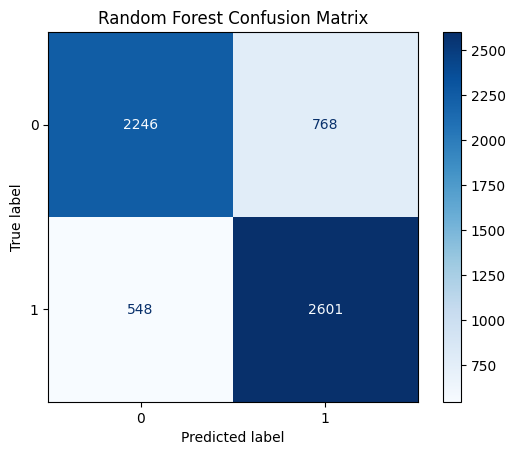

In [28]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Display confusion matrix
ConfusionMatrixDisplay.from_predictions(
    y_test,
    pred,
    cmap="Blues"
)

plt.title("Random Forest Confusion Matrix")
plt.show()

In [29]:
# Get transformed feature names
feature_names = model.named_steps["preprocessor"].get_feature_names_out()

# Get feature importance
importances = model.named_steps["classifier"].feature_importances_

importance_df = (
    pd.DataFrame({
        "Feature": feature_names,
        "Importance": importances
    })
    .sort_values("Importance", ascending=False)
)

importance_df.head(10)

,Feature,Importance
66,num__impressions_prev_30d,0.153010
63,num__impressions_last_30d,0.116254
53,num__impressions_90d,0.068602
73,num__avg_position,0.051441
61,num__days_with_impressions,0.048433
69,num__content_age_days,0.037296
51,num__word_count,0.029038
65,num__sessions_last_30d,0.028322
52,num__char_count,0.026764
72,num__ctr,0.025241


## Feature Interpretation

The model relied most heavily on engagement, traffic, and search performance features. These features are reasonable indicators of whether content is declining and do not include identifiers or leakage variables.

The importance values suggest the model is learning meaningful relationships from the available content performance data rather than memorizing client-specific information.

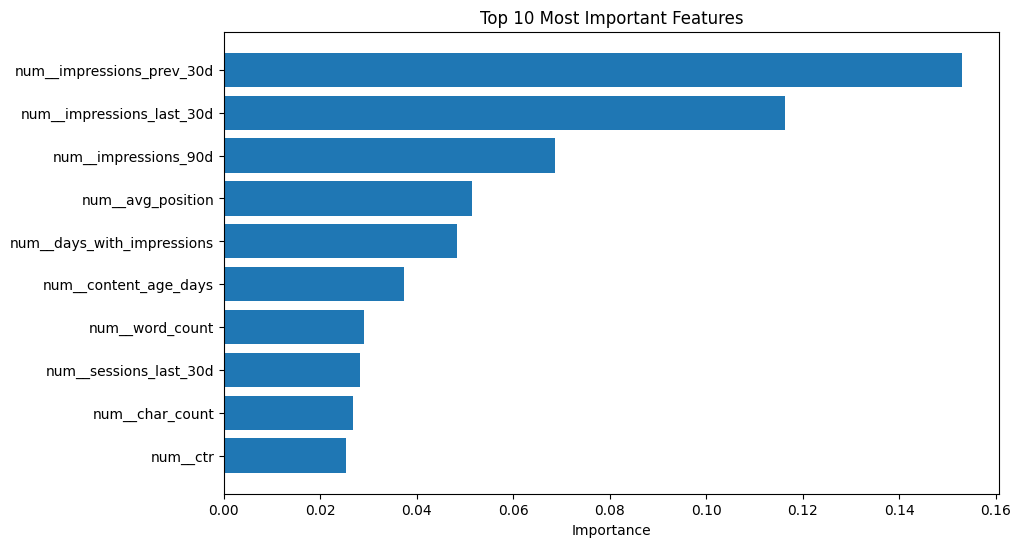

In [30]:
plt.figure(figsize=(10,6))

plt.barh(
    importance_df["Feature"].head(10),
    importance_df["Importance"].head(10)
)

plt.gca().invert_yaxis()
plt.title("Top 10 Most Important Features")
plt.xlabel("Importance")
plt.show()

In [31]:
# Find wrong predictions
errors = X_test.copy()
errors["Actual"] = y_test.values
errors["Predicted"] = pred

misclassified = errors[errors["Actual"] != errors["Predicted"]]

print("Number of Misclassified Samples:", len(misclassified))

misclassified.head(3)

Number of Misclassified Samples: 1316


,search_volume,competition,competition_level,cpc,content_type,main_intent,word_count,char_count,provider_used,model_used,...,char_count_tier,ctr,avg_position,engagement_rate,scroll_rate,ai_traffic_pct,impression_tier,position_tier,Actual,Predicted
1,90.0,0.01,LOW,0.05,keyword article,informational,2481.0,15562.0,NaN,gemini-3-flash-preview,...,15000-25000,0.05,20.3,0.0,10.00,0.0,good,page_3_5,1,0
13,10.0,0.00,LOW,0.00,keyword article,informational,1342.0,8469.0,NaN,gpt-4o-mini,...,8000-15000,0.00,39.8,0.0,25.00,0.0,moderate,page_3_5,0,1
26,0.0,0.00,LOW,0.00,keyword article,informational,2686.0,17181.0,NaN,gemini-3-flash-preview,...,15000-25000,0.12,30.0,0.0,11.11,0.0,moderate,page_3_5,0,1


## Conclusion

A Random Forest classifier was trained using a grouped train-test split and compared against the Week 4 baseline on the same prediction task.

The model achieved:

- Accuracy: **78.65%**
- Precision: **77.20%**
- Recall: **82.60%**
- F1 Score: **79.81%**

The results suggest that the model captures meaningful patterns related to declining content and can support content refresh decisions while remaining interpretable through feature importance analysis.

## Self-check

Before you submit, confirm each line honestly:

- [x] Every section above is filled — markdown thinking AND the code that backs it
- [x] The notebook runs top to bottom with no errors (Runtime → Run all)
- [x] No client names, URLs, or private queries anywhere
- [x] My claims use careful words: observed, measured, directional, decision-support
- [x] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.